<a href="https://colab.research.google.com/github/ogc1231/mole_classification_deep_learning/blob/main/Deepl_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# install kaggle
!pip install kaggle

In [3]:
# upload kaggle API key, kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ogc1231","key":"9ad0f56f60f271638145976c763f3e2e"}'}

In [4]:
# get and set kaggle credentials
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import random
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [8]:
DATA_DIR = "./HAM10000"
ZIP_FILE = os.path.join(DATA_DIR, "skin-cancer-mnist-ham10000.zip")

# Make sure the folder exists
os.makedirs(DATA_DIR, exist_ok=True)

# Download only if ZIP doesn't exist
if not os.path.exists(ZIP_FILE):
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p {DATA_DIR}

# Unzip only if images folder doesn't exist
IMG_DIR = os.path.join(DATA_DIR, "HAM10000_images_part_1")
if not os.path.exists(IMG_DIR):
    !unzip -q {ZIP_FILE} -d {DATA_DIR}

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.18G/5.20G [04:04<00:00, 138MB/s]
100% 5.20G/5.20G [04:05<00:00, 22.8MB/s]


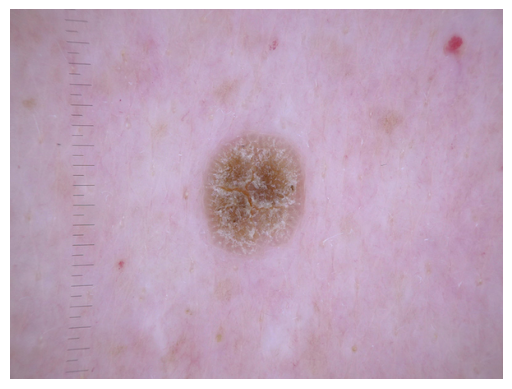

In [31]:
all_images = [f for f in os.listdir(IMG_DIR) if f.endswith(".jpg")]
sample_img = os.path.join(IMG_DIR, random.choice(all_images))

image = Image.open(sample_img)
plt.imshow(image)
plt.axis('off')
plt.show()